# Grão Certo
### Classificação de variedades de arroz

Nome: **Bernardo Roosevelt** · Disciplina: **Inteligência Artificial** · Professor: **Claudomiro Sales**

## Índice

1. [Ideia da startup](#scrollTo=ideia)
2. [Dataset escolhido](#scrollTo=dataset)
3. [Atributos e classe](#scrollTo=atributos)
4. [Uso da IA durante a disciplina](#scrollTo=plano)
5. [Tratamento dos dados](#scrollTo=tratamento)
6. [Comparação dos atributos](#scrollTo=grafico)
7. [Próximos passos](#scrollTo=proximos)
8. [Referências](#scrollTo=referencias)


## 1. Ideia da startup

Minha ideia é criar um sistema que ajude beneficiadoras de arroz a identificar a variedade de um grão pelas suas medidas.

- Ideia central do negócio é conferir a variedade dos grãos de um lote a qual pode ser útil para a beneficiadora. Quero confirmar isso conversando com quem trabalha na área.
- Vou começar com duas variedades: Cammeo e Osmancik.
- Nesse protótipo, o sistema recebe as 7 medidas e responde a variedade, em um produto real uma das medidas utilizadas são pixels então será baseado em frames dos grãos para a IA diferenciar.(por enquanto são "medidas enviadas", porém no futuro será fotos, pois é muito mais comerciável usar fotos do que cobrar medidas muito precisas da empresa podendo acabar espantando alguns clientes ou muitos).
- A ideia de negócio é cobrar uma mensalidade pelo uso. Focar no uso contínuo do cliente.

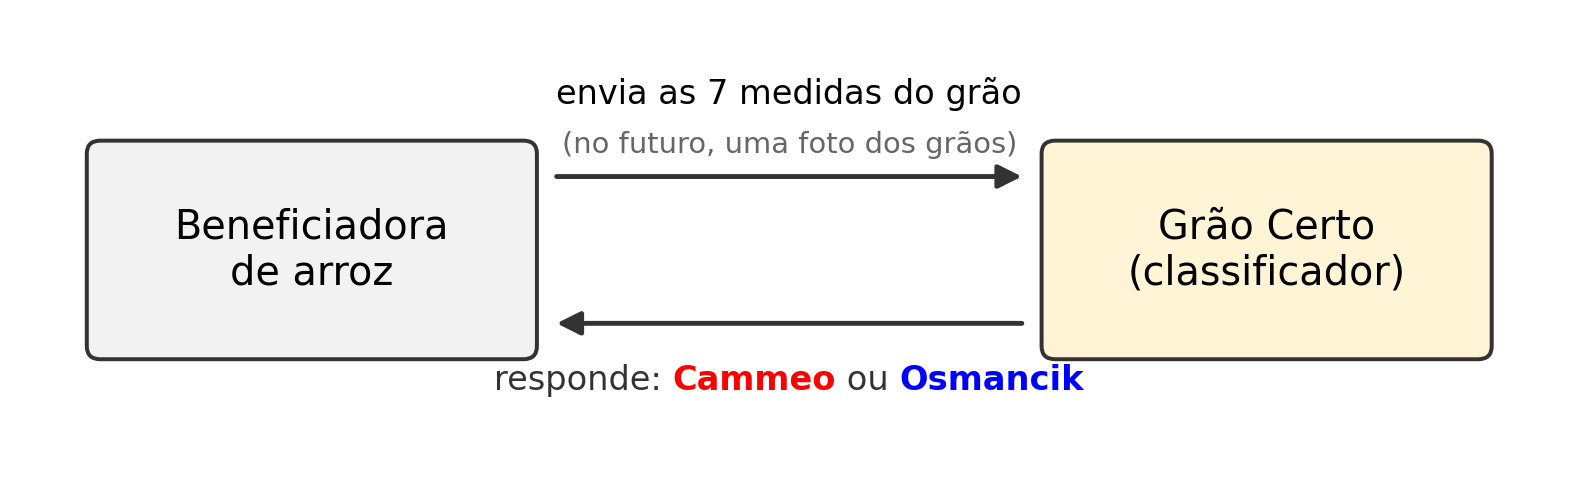

## 2. Dataset escolhido

Rice (Cammeo and Osmancik), do UCI Machine Learning Repository.

- 3.810 grãos, com 7 medidas cada.
- Cada linha já vem com a variedade (Cammeo ou Osmancik).
- As medidas foram tiradas de fotos dos grãos pelos autores da base.

Escolhi essa base porque ela tem atributos numéricos e duas classes, como o exemplo da aula.

## 3. Atributos e classe

| Atributo | O que representa |
|---|---|
| `Area` | Área do grão na imagem |
| `Perimeter` | Perímetro do contorno |
| `Major_Axis_Length` | Comprimento do eixo maior |
| `Minor_Axis_Length` | Comprimento do eixo menor |
| `Eccentricity` | Excentricidade da elipse ajustada |
| `Convex_Area` | Área do menor envoltório convexo |
| `Extent` | Proporção ocupada no retângulo delimitador |

Na coluna `Class`, vou substituir Cammeo por 1 e Osmancik por 0.

## 4. Uso da IA durante a disciplina

Pretendo treinar um classificador para reconhecer as duas variedades usando as sete medidas.

1. separar dados de treino e teste.
2. padronizar as medidas usando os dados de treino.
3. começar com um Perceptron e analisar seus acertos e erros no teste.
4. criar uma interface para receber as medidas de novos grãos.

Nessa atividade, só organizo e comparo os dados.

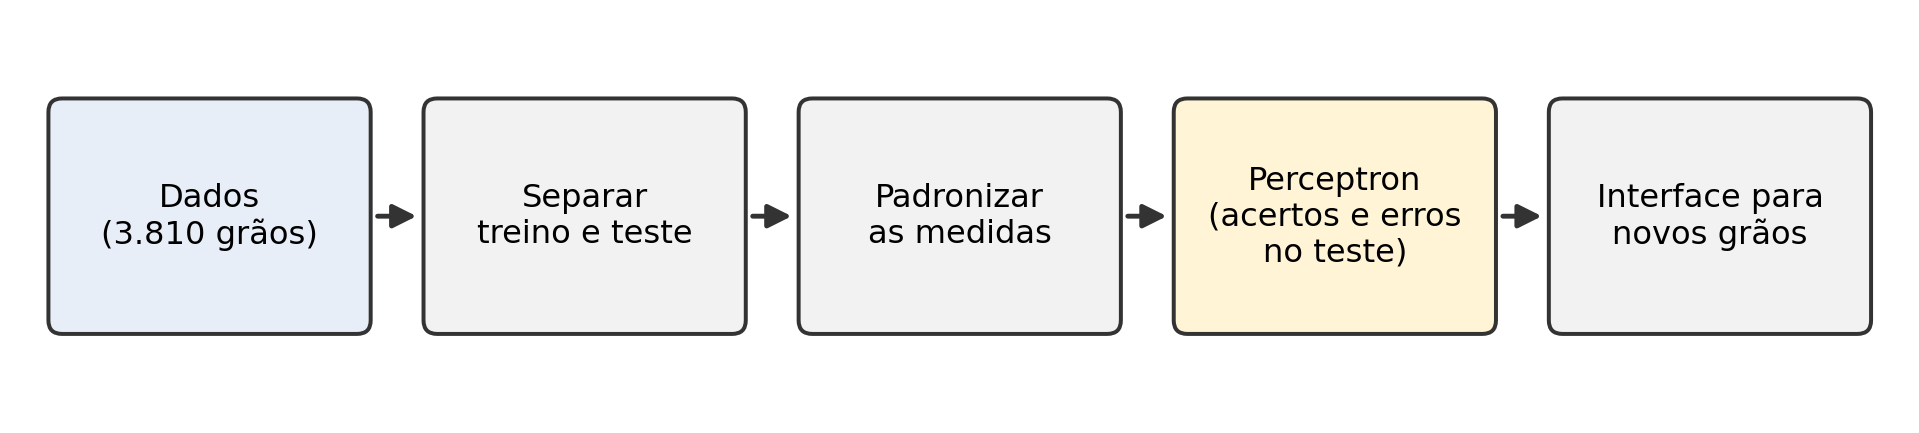

## 5. Tratamento dos dados

Vou ler a tabela, conferir as colunas e transformar a classe em número.

Diferente do arquivo MAGIC da aula, este CSV já tem cabeçalho, então uso `header=0` junto com `names`.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = "retina"

**Dataset:**

Cinar, I. e Koklu, M. (2019). Rice (Cammeo and Osmancik). UCI Machine Learning Repository https://doi.org/10.24432/C5MW4Z

Doado por: Ilkay Cinar e Murat Koklu, Selcuk University, Konya, Turquia.

In [11]:
#leitura e nomes das colunas
url = "https://archive.ics.uci.edu/static/public/545/data.csv"
colunas = [
    "Area", "Perimeter", "Major_Axis_Length", "Minor_Axis_Length",
    "Eccentricity", "Convex_Area", "Extent", "Class"
]

df = pd.read_csv(url, header=0, names=colunas)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [12]:
#conferir estrutura e tipos
print("Linhas e colunas:", df.shape)
df.info()

Linhas e colunas: (3810, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


In [13]:
#conferir valores ausentes e classes antes da conversão
print("Valores ausentes por coluna:")
print(df.isna().sum())
print("\nRegistros por classe:")
print(df["Class"].value_counts())

Valores ausentes por coluna:
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64

Registros por classe:
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


Agora troco a classe por número: Cammeo = 1 e Osmancik = 0, do mesmo jeito que foi demonstrado em aula com o dataset dos raios gama e hadron.

In [14]:
#converter a classe para número
df["Class"] = (df["Class"] == "Cammeo").astype(int)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,1
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,1
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,1
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,1
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,1


In [15]:
#separar as features (X) e a classe (y) em arrays NumPy
X = np.array(df.iloc[:, :7], dtype=float)
y = np.array(df["Class"], dtype=int)

print("X:", X.shape, "— linhas e atributos")
print("y:", y.shape, "— classes")
print("Primeiro grão:", X[0])
print("Classe do primeiro grão:", y[0])

X: (3810, 7) — linhas e atributos
y: (3810,) — classes
Primeiro grão: [1.52310000e+04 5.25578979e+02 2.29749878e+02 8.50937881e+01
 9.28882003e-01 1.56170000e+04 5.72895527e-01]
Classe do primeiro grão: 1


## 6. Comparação dos atributos

Comparo os atributos dois a dois. Os quatro pares abaixo cobrem as sete medidas.

Cada ponto é um grão: círculos vermelhos são Cammeo e cruzes azuis são Osmancik.

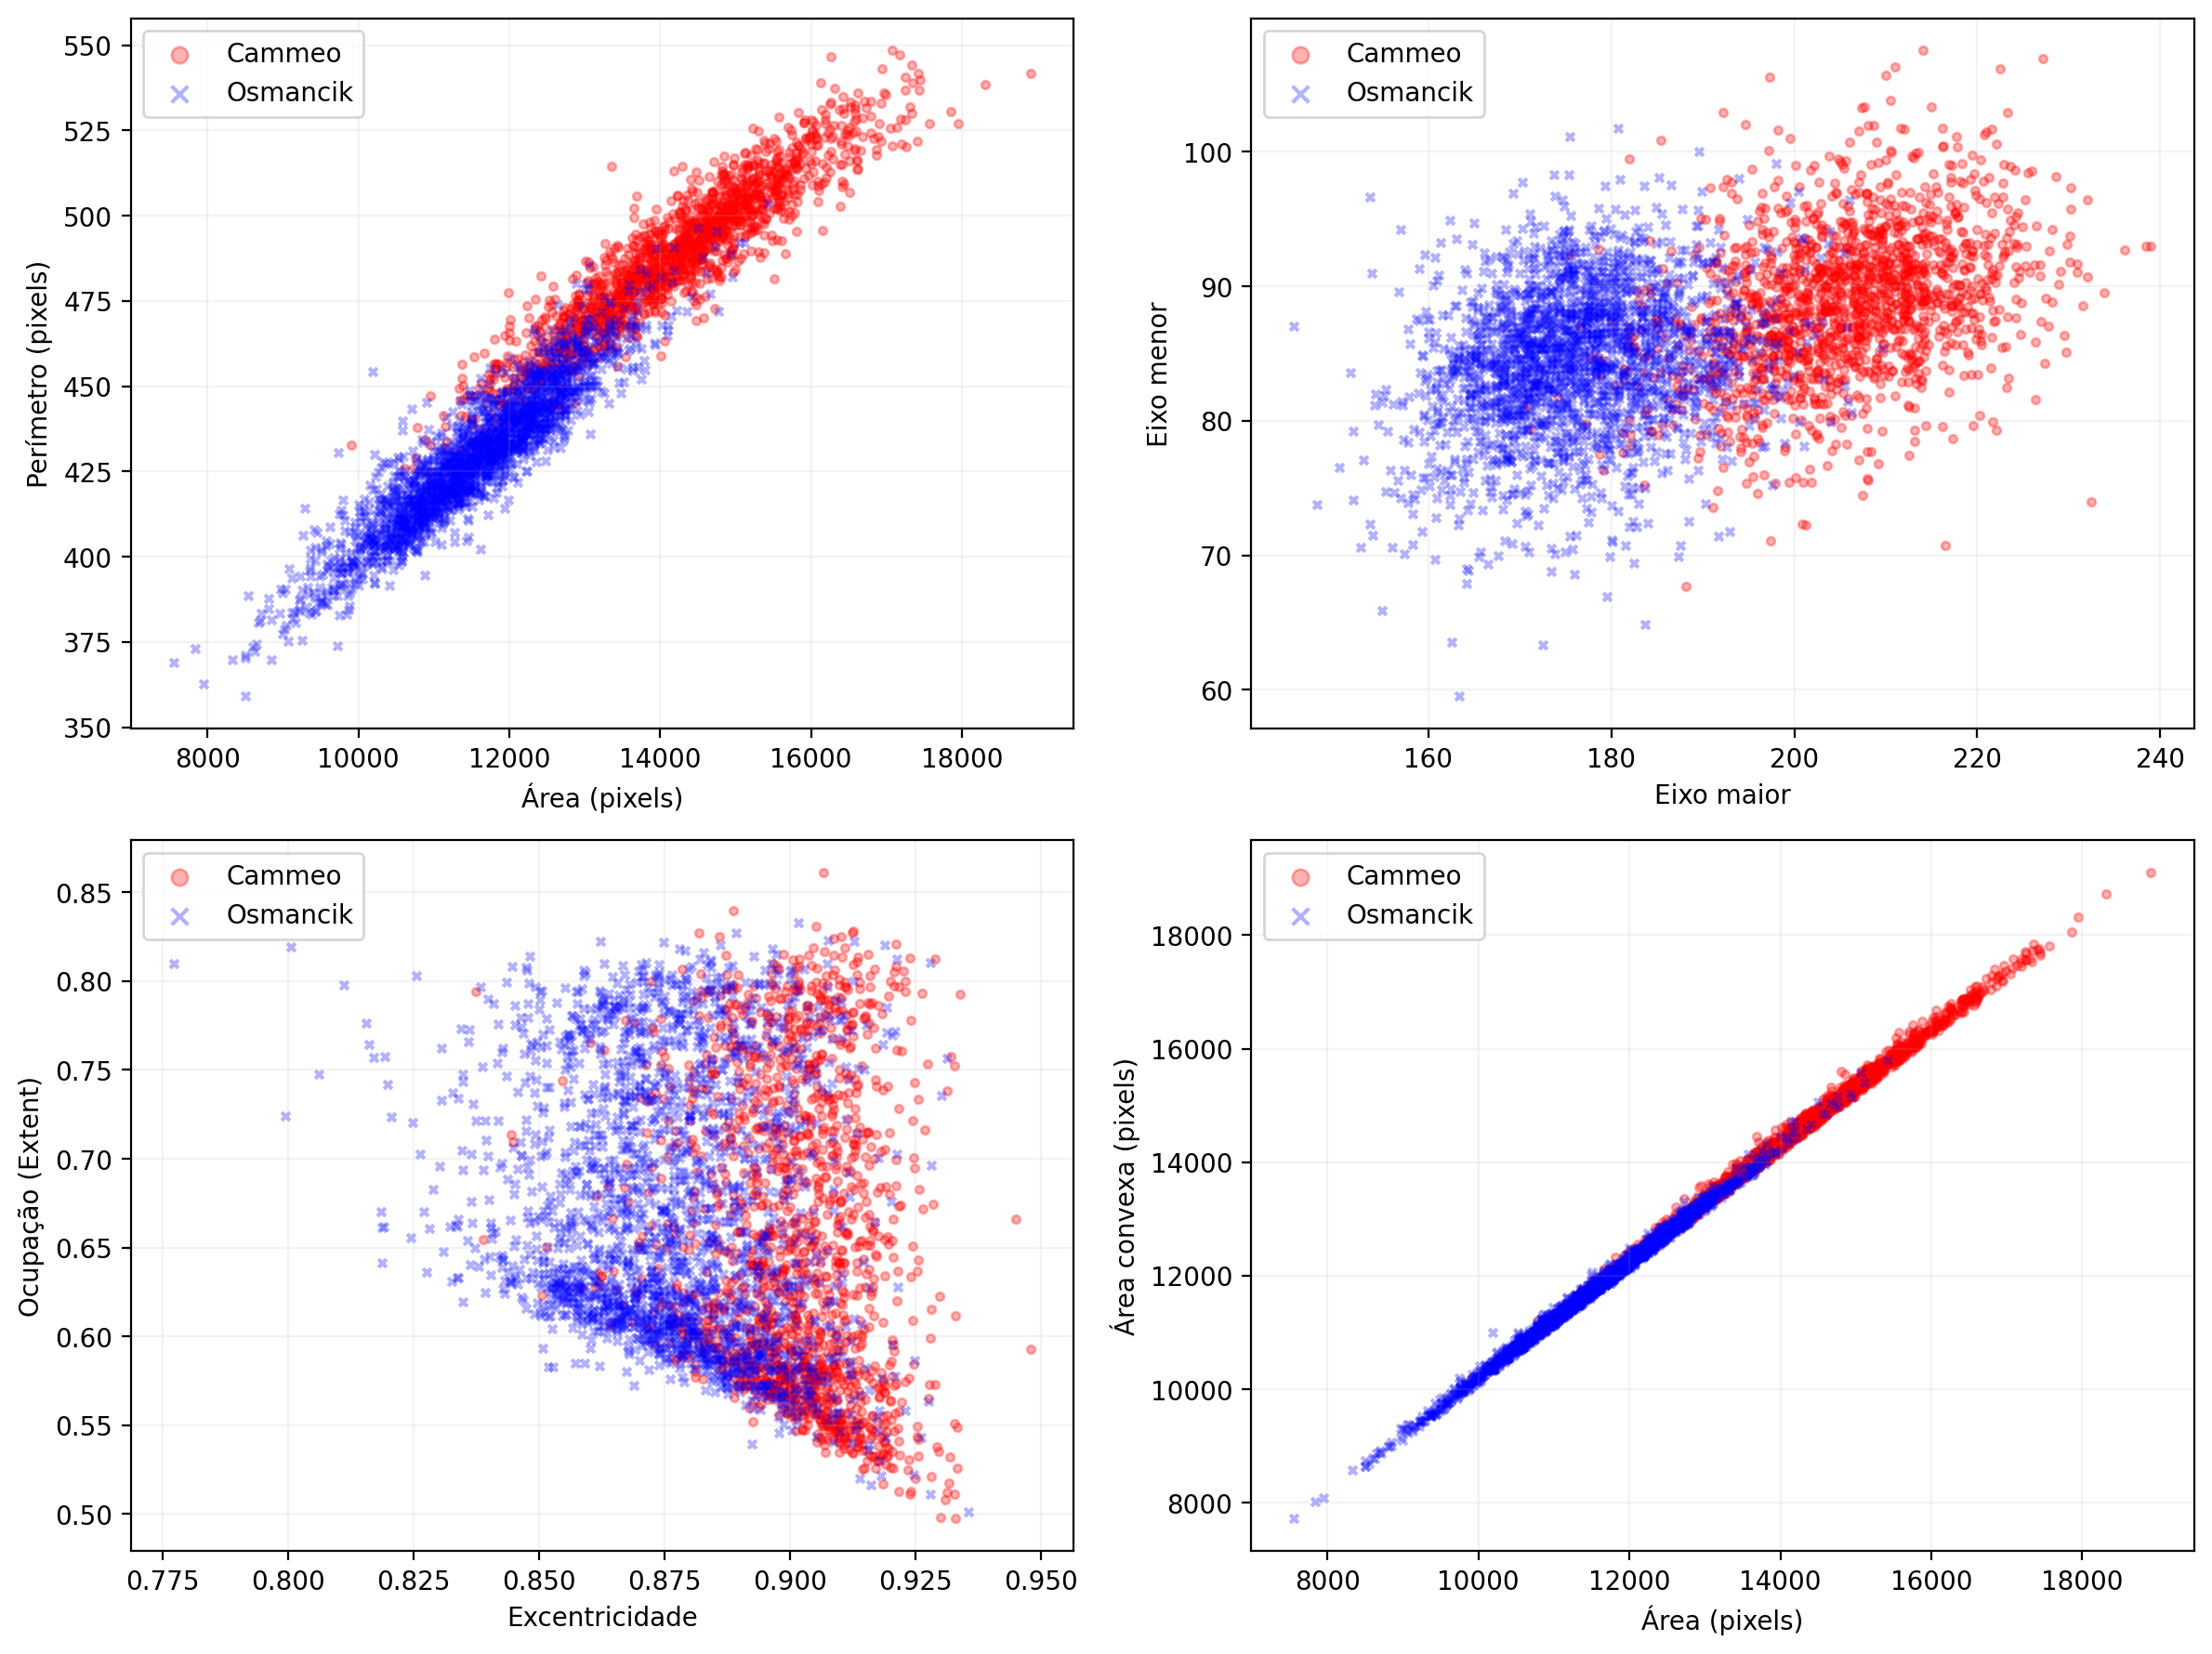

In [16]:
#indices das colunas de X 0=Area, 1=Perimeter, 2=Major_Axis_Length
#3=Minor_Axis_Length, 4=Eccentricity, 5=Convex_Area, 6=Extent
pares = [(0, 1), (2, 3), (4, 6), (0, 5)]
rotulos = ["Área (pixels)", "Perímetro (pixels)", "Eixo maior",
           "Eixo menor", "Excentricidade", "Área convexa (pixels)", "Ocupação (Extent)"]

fig, eixos = plt.subplots(2, 2, figsize=(12, 9))

for eixo, (a, b) in zip(eixos.flat, pares):
    eixo.scatter(X[y == 1, a], X[y == 1, b],
                 color="red", marker="o", label="Cammeo", s=10, alpha=0.3)
    eixo.scatter(X[y == 0, a], X[y == 0, b],
                 color="blue", marker="x", label="Osmancik", s=10, alpha=0.3)
    eixo.set_xlabel(rotulos[a])
    eixo.set_ylabel(rotulos[b])
    eixo.legend(markerscale=2)
    eixo.grid(alpha=0.15)

plt.tight_layout()
plt.show()

In [17]:
#Médias de cada atributo nas duas variedades
medias = df.groupby("Class")[colunas[:7]].mean().T
medias.columns = ["Osmancik", "Cammeo"]
medias.round(3)

,Osmancik,Cammeo
Area,11549.783,14162.892
Perimeter,429.416,487.439
Major_Axis_Length,176.288,205.479
Minor_Axis_Length,84.479,88.768
Eccentricity,0.876,0.901
Convex_Area,11799.586,14494.427
Extent,0.670,0.651


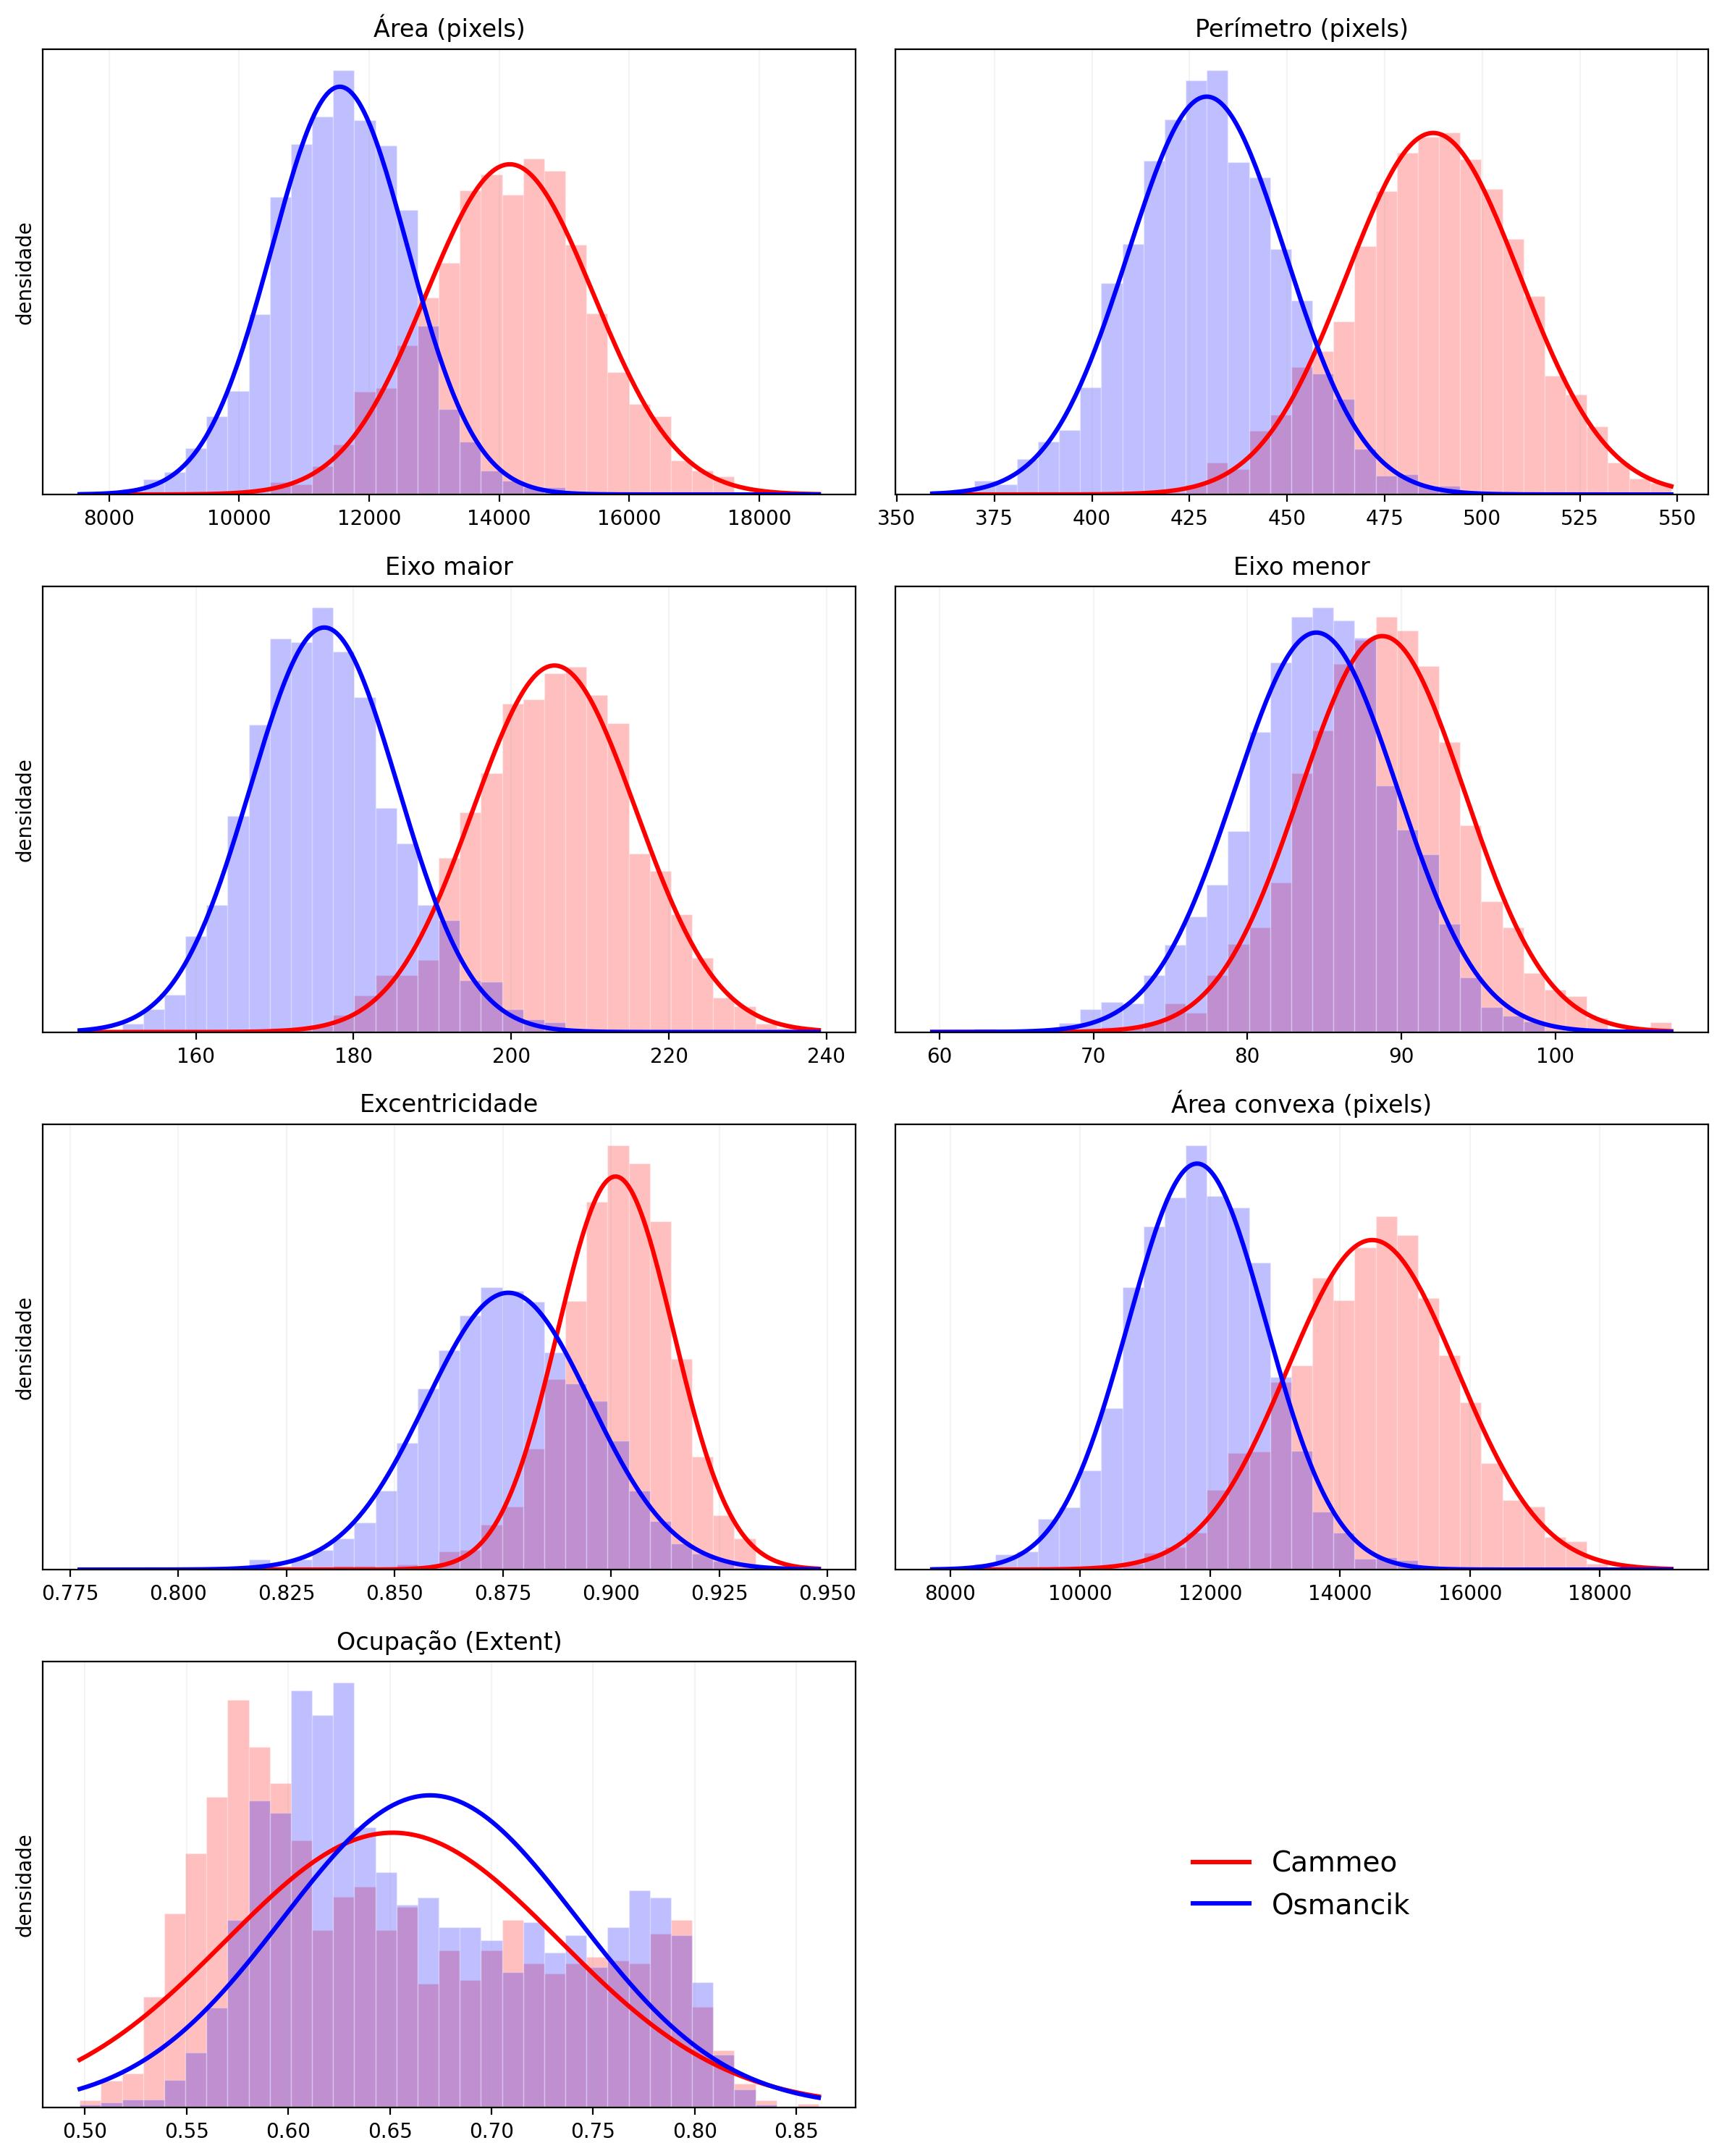

In [18]:
#histograma de cada atributo com a curva gaussiana ajustada
def gaussiana(x, media, desvio):
    return np.exp(-(x - media)**2 / (2 * desvio**2)) / (desvio * np.sqrt(2 * np.pi))

fig, eixos = plt.subplots(4, 2, figsize=(12, 15))

for i, eixo in enumerate(eixos.flat[:7]):
    faixa = np.linspace(X[:, i].min(), X[:, i].max(), 300)
    bins = np.linspace(X[:, i].min(), X[:, i].max(), 36)
    for classe, cor, nome in [(1, "red", "Cammeo"), (0, "blue", "Osmancik")]:
        valores = X[y == classe, i]
        media, desvio = valores.mean(), valores.std()
        eixo.hist(valores, bins=bins, density=True, color=cor, alpha=0.25,
                  edgecolor="white", linewidth=0.5)
        eixo.plot(faixa, gaussiana(faixa, media, desvio), color=cor, linewidth=2.2, label=nome)
    eixo.set_title(rotulos[i], fontsize=12)
    eixo.set_yticks([])
    eixo.grid(alpha=0.15)
    if i % 2 == 0:
        eixo.set_ylabel("densidade")

eixos.flat[7].axis("off")
eixos.flat[7].legend(*eixos.flat[0].get_legend_handles_labels(),
                     loc="center", fontsize=14, frameon=False)

plt.tight_layout()
plt.show()

- Em média, o Cammeo é maior já que tem mais área, mais perímetro e é bem mais comprido (eixo maior) percebe-se então que essas features parecem ajudar mais na separacao dos graos visto que as outras como o (Minor_Axis_Length) são muito próximas uma das outras e pelos gráficos é perceptível que algumas se sobrepõe bastante, porém é necessário aplicar o treinamento para afirmar assertivamente como os dados agem no treinamento.
- O gráfico de eixo maior × eixo menor é o que mais separa as duas variedades.
- Área e área convexa sao graficos parecidos que parecem formar uma reta y=ax+b.
- Existe uma faixa em que as duas variedades se sobrepoem então é esperado que o modelo no futuro erre alguns grãos, mas como tudo no mundo tem margem de erro a preocupação é minimizá-la o máximo possível.

## 7. Próximos passos

- Treinar o Perceptron e ver quantos grãos ele acerta no teste.
- Para usar fotos reais, o sistema teria que extrair as medidas automaticamente, com câmera e distância padronizadas, porque várias medidas estão em pixels.
- Conversar com alguem que tenha experiencia no mercado e pedir a sua avaliacao para ver se a ideia é viável no mercado, se ja nao existe um monopolio e varias outras coisas que talvez gere obstaculos na hora da aplicacao real.
- Caso a ideia vá para frente, provavelmente terei que reconhecer algumas dezenas de tipo de arroz em empresas ou talvez ate adicionar uma funcao de reconhecer quando o grao esta estragado e etc, mas para conseguir realizar isso precisarei de novos dados.

## 8. Referências

- Cinar, I. e Koklu, M. (2019). [Rice (Cammeo and Osmancik)](https://doi.org/10.24432/C5MW4Z). UCI Machine Learning Repository. Licença CC BY 4.0.
- [CSV utilizado](https://archive.ics.uci.edu/static/public/545/data.csv).